# A gentle introduction to Artificial Intelligence

---
## What is AI? What is Machine Learning?

<p align="center">
  <img src="https://raw.githubusercontent.com/Hunter174/GentleIntroToML/main/assets/ai-ml-dl_bubbles.png" width="800"/>
</p>

Artificial Intelligence is a broad field focused on building systems that can perform tasks requiring **human-like intelligence**, such as reasoning, perception, and decision-making.

Within AI, there are several important subfields:

---

### 🧠 Artificial Intelligence (AI)
The umbrella field.  
Any system designed to mimic aspects of human intelligence.

---

### 📊 Machine Learning (ML)
A subset of AI where models **learn patterns from data** rather than being explicitly programmed.

> Instead of writing rules, we let the model discover them.

---

### 🔗 Deep Learning (DL)
A subset of ML that uses **neural networks with multiple layers** to learn complex patterns.

- Particularly effective for images, language, and large-scale data

---

### ✨ Generative AI (GenAI)
Models that **generate new content** based on learned patterns.

- Examples: text (ChatGPT), images, code generation

---

## 🧭 Key Idea

> AI is the broad goal,  
> ML is how we learn from data,  
> DL is a powerful approach within ML.

---
## Types of Machine Learning

Machine learning problems are typically grouped into two main categories based on the type of data available:

---

### 📌 1. Supervised Learning

In supervised learning, we provide the model with:

- **Inputs (features)**  
- **Correct outputs (labels)**  

The goal is for the model to learn a mapping from inputs → outputs.

**Examples:**
- Predicting house prices  
- Classifying emails as spam or not spam  

> The model learns by comparing its predictions to the correct answers.

---

### 🔍 2. Unsupervised Learning

In unsupervised learning, we provide only:

- **Inputs (no labels)**  

The model must discover structure or patterns on its own.

**Examples:**
- Grouping similar customers (clustering)  
- Detecting unusual behavior (anomaly detection)  

> There are no “correct answers” — the model explores the data.

---

<p align="center">
  <img src="https://raw.githubusercontent.com/Hunter174/GentleIntroToML/main/assets/supervised-vs-unsupervised_learning.png" width="800"/>
</p>

---

## 🧭 Key Idea

> Supervised learning learns from **answers**,  
> Unsupervised learning finds patterns **without answers**.

---
# 🌸 Problem 1: Iris Dataset (Classification)

We will walk through a complete machine learning workflow:

> **Visualize → Train → Predict**

---

## 📊 The Dataset

The Iris dataset is a classic dataset used for **classification problems**.

Each row represents a flower, and we are given measurements such as:

- Sepal length  
- Sepal width  
- Petal length  
- Petal width  

---

## 🎯 Goal

Given these measurements, we want to predict:

> **Which type of iris flower is it?**

- Setosa  
- Versicolor  
- Virginica  

---

## 🧠 What to expect

- This is a **supervised learning problem**
- The model will learn patterns that separate the different flower types
- Later, we will visualize how models make these decisions

---

In [173]:
from sklearn.datasets import load_iris

# Load dataset
iris_data = load_iris(as_frame=True)
iris_df = iris_data.frame

# Split features and target
iris_X = iris_df.drop(columns=["target"])
iris_y = iris_df["target"]

# Preview data
display(iris_df.head())

# Summary statistics
display(iris_df.describe())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


---
## ⚖️ Why do we standardize features?

Before training many machine learning models, we often **standardize** the input features.

Standardization rescales each feature so that it has:

- Mean = 0  
- Standard deviation = 1  

---

## 🧠 Why is this important?

Different features can have very different scales:

- Petal length might range from 1 → 6  
- Sepal width might range from 2 → 4  

Without scaling, features with larger values can **dominate the model**, even if they are not more important.

---

## 🔍 Especially important for PCA

Principal Component Analysis (PCA) works by finding directions of **maximum variance**.

> If features are not standardized, PCA will be biased toward features with larger scales.

This can lead to misleading visualizations and poor representations of the data.

---

## ⚙️ Models that benefit from standardization

- Logistic Regression  
- Neural Networks  
- K-Nearest Neighbors  
- PCA  

(Models like Random Forests are less sensitive to scaling.)

---

## 🧭 Key Idea

> Standardization ensures that all features contribute **fairly** to the model.

In [174]:
from sklearn.preprocessing import StandardScaler

# Features and target (Iris-specific naming)
iris_X = iris_df.drop(columns=["target"])
iris_y = iris_df["target"]

# Standardize features (important for PCA and many models)
scaler = StandardScaler()
iris_X_scaled = scaler.fit_transform(iris_X)

---
## 🔍 Exploratory Data Analysis (EDA)

Before training a model, it is important to **explore the data** to understand its structure and patterns.

Exploratory Data Analysis (EDA) helps us:

- Visualize how data points are distributed  
- Identify patterns or separability between classes  
- Detect potential issues (outliers, overlap, scaling problems)  

---

## 🧠 Why use PCA for visualization?

Our dataset has multiple features, which makes it difficult to visualize directly.

We use **Principal Component Analysis (PCA)** to:

- Reduce the data to **2 dimensions**
- Preserve as much important structure as possible
- Enable us to **plot and inspect the data visually**

---

## 👀 What to look for

When viewing the plot:

- Are the classes clearly separated?  
- Do some classes overlap?  
- How complex might the decision boundary need to be?  

---

## 🧭 Key Idea

> EDA helps us build intuition about the problem **before** we train a model.

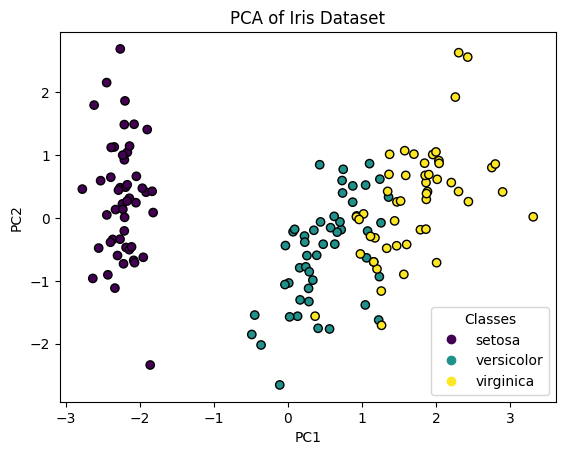

In [176]:
#@title Exploratory Data Analysis (PCA Visualization)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- PCA (on standardized Iris features) ---
pca = PCA(n_components=2)
iris_X_pca = pca.fit_transform(iris_X_scaled)

# --- Plot ---
plt.figure()

scatter = plt.scatter(
    iris_X_pca[:, 0],
    iris_X_pca[:, 1],
    c=iris_y,
    cmap="viridis",
    edgecolor="k"
)

# Legend with class names
handles, _ = scatter.legend_elements()
labels = iris_data.target_names
plt.legend(handles, labels, title="Classes")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Iris Dataset")

plt.show()

---
## 🧪 Why do we need a train/test split?

When we train a model, it learns patterns from the data we provide.

If we evaluate the model on the **same data it was trained on**, it may appear to perform very well—even if it has simply **memorized** the data rather than learned general patterns.

<p align="center">
  <a href="https://mlu-explain.github.io/train-test-validation/">
    🔗 Interactive explanation: Train vs Test vs Validation
  </a>
</p>

---

## 📊 How we evaluate properly

To measure real performance, we split the data into:

- **Training set** → used to train the model  
- **Test set** → used to evaluate how well the model generalizes to **unseen data**

---

## 🧠 Key Idea

> A model is only useful if it performs well on data it has **never seen before**

---

## 🔁 Going further: Cross-Validation

A single train/test split can still be sensitive to how the data is divided.

To get a more reliable estimate, we use **cross-validation**, which evaluates the model across multiple splits.

<p align="center">
  <a href="https://mlu-explain.github.io/cross-validation/">
    🔗 Interactive explanation: Cross-Validation
  </a>
</p>

In [177]:
#@title Train/Test Split (Iris Dataset)

from sklearn.model_selection import train_test_split

iris_X_train, iris_X_test, iris_y_train, iris_y_test = train_test_split(
    iris_X_scaled,
    iris_y,
    test_size=0.2,       # 20% for testing
    random_state=42      # Ensures reproducibility
)

---
# 📈 Logistic Regression (Classification)

Logistic regression is a **classification model** that predicts the **probability of a class**.

Instead of predicting a continuous value, it outputs probabilities that are used to assign a class label.

<p align="center">
  <img src="https://raw.githubusercontent.com/Hunter174/GentleIntroToML/main/assets/what-is-logistic-regression.png" width="400"/>
</p>

---

## 🧠 How it works

- Learns a **linear boundary** between classes  
- Uses a function to convert outputs into probabilities  
- Assigns the class with the highest probability  

---

## ⚙️ What to explore

Adjust the parameters below and observe:

- **Max Iterations** → Does the model converge?  
- **Regularization (C)** → Simpler vs more flexible boundary  
- **Solver** → Different optimization strategies  

---

## 👀 What to look for

- Are the classes well separated?  
- Does the boundary look too simple for the data?  
- How do parameter changes affect the boundary?

---

For an interactive, visual explanation, see:  
🔗 https://mlu-explain.github.io/logistic-regression/

Accuracy: 96.667%


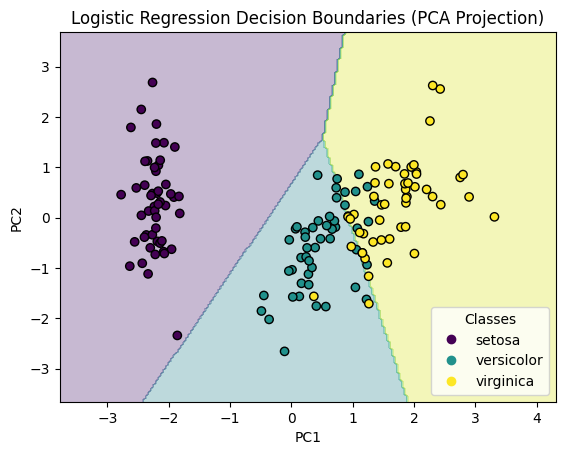

In [178]:
#@title Logistic Regression Interactive Demo (Iris) { run: "auto" }

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# --- Controls ---
Max_Iterations = 29 #@param {type:"slider", min:1, max:200, step:1}
Regularization_C = 5.26 #@param {type:"slider", min:0.01, max:10.0, step:0.01}
Solver = "liblinear" #@param ["lbfgs", "liblinear", "newton-cg"]

# =========================
# 🔹 Train model (Iris dataset)
# =========================
iris_logreg_model = LogisticRegression(
    max_iter=Max_Iterations,
    C=Regularization_C,
    solver=Solver,
)

iris_logreg_model.fit(iris_X_train, iris_y_train)

accuracy = iris_logreg_model.score(iris_X_test, iris_y_test)
print(f"Accuracy: {accuracy*100:.3f}%")

# =========================
# 🔹 Train model on PCA (for visualization)
# =========================
iris_logreg_model_pca = LogisticRegression(
    max_iter=Max_Iterations,
    C=Regularization_C,
    solver=Solver,
)

iris_logreg_model_pca.fit(iris_X_pca, iris_y)

# =========================
# 🔹 Create mesh grid
# =========================
x_min, x_max = iris_X_pca[:, 0].min() - 1, iris_X_pca[:, 0].max() + 1
y_min, y_max = iris_X_pca[:, 1].min() - 1, iris_X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# =========================
# 🔹 Predict
# =========================
Z = iris_logreg_model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# =========================
# 🔹 Plot
# =========================
plt.figure()

plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

scatter = plt.scatter(
    iris_X_pca[:, 0],
    iris_X_pca[:, 1],
    c=iris_y,
    cmap="viridis",
    edgecolor="k"
)

handles, _ = scatter.legend_elements()
labels = iris_data.target_names
plt.legend(handles, labels, title="Classes")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Logistic Regression Decision Boundaries (PCA Projection)")

plt.show()

---
## ⚠️ Limitation of PCA Visualizations

In the previous plot, we visualized the data in **2 dimensions using PCA**.

However, the original Iris dataset has **4 features**.

This means:

> We are projecting higher-dimensional data into a lower-dimensional space.

---

## 🧠 Why this matters

When we reduce dimensions:

- Some information is **lost**
- Class separation may appear worse than it actually is
- Decision boundaries can look misleading

---

## 🔍 What to observe

Even if the 2D plot shows overlap:

- The model may still achieve **high accuracy**
- This is because the model sees the data in **full 4D space**

---

## 🚀 Improving the visualization

To better understand the structure, we can:

- Project the data into **3 dimensions instead of 2**
- Interactively rotate the view
- Observe how separation improves

---

## 🧭 Key Idea

> Visualizations are approximations —  
> models operate in the **full feature space**, not just what we can see.

In [179]:
#@title 3D PCA Visualization (Interactive - Iris)

import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# =========================
# 🔹 PCA to 3D (from standardized Iris data)
# =========================
pca3 = PCA(n_components=3)
iris_X_pca3 = pca3.fit_transform(iris_X_scaled)

# =========================
# 🔹 Train model (on PCA space for visualization)
# =========================
iris_logreg_model_3d = LogisticRegression(max_iter=200)
iris_logreg_model_3d.fit(iris_X_pca3, iris_y)

# =========================
# 🔹 Create 3D grid
# =========================
grid_size = 30

x_range = np.linspace(iris_X_pca3[:, 0].min() - 1, iris_X_pca3[:, 0].max() + 1, grid_size)
y_range = np.linspace(iris_X_pca3[:, 1].min() - 1, iris_X_pca3[:, 1].max() + 1, grid_size)
z_range = np.linspace(iris_X_pca3[:, 2].min() - 1, iris_X_pca3[:, 2].max() + 1, grid_size)

xx, yy, zz = np.meshgrid(x_range, y_range, z_range)
grid = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]

# =========================
# 🔹 Predict over grid
# =========================
Z = iris_logreg_model_3d.predict(grid)

# =========================
# 🔹 Plot
# =========================
fig = go.Figure()

# Scatter points
fig.add_trace(go.Scatter3d(
    x=iris_X_pca3[:, 0],
    y=iris_X_pca3[:, 1],
    z=iris_X_pca3[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=iris_y,
        colorscale='Viridis',
        opacity=0.9
    ),
    text=[iris_data.target_names[i] for i in iris_y],
    name='Data'
))

# Decision boundary (approximation)
fig.add_trace(go.Isosurface(
    x=xx.flatten(),
    y=yy.flatten(),
    z=zz.flatten(),
    value=Z,
    isomin=0.5,
    isomax=2.5,
    opacity=0.2,
    surface_count=3,
    colorscale='Viridis',
    showscale=False
))

# Layout
fig.update_layout(
    title="3D Logistic Regression Decision Boundaries (PCA Projection)",
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3"
    )
)

fig.show()

---
# 🚢 Problem 2: Titanic Dataset (Real-World Data)

So far, we’ve worked with clean, numeric datasets.

Real-world data is often much messier.

The Titanic dataset introduces new challenges:

- Missing values  
- Categorical features (e.g., "male", "female")  
- Mixed data types  

---

## 🎯 Goal

Predict whether a passenger survived based on:

- Age  
- Fare  
- Passenger class  
- Sex  
- Embarkation port  

---

## ⚠️ Why this is different

Unlike the Iris dataset:

- We **cannot directly feed this data into a model**
- Models require **numeric input**
- We must preprocess the data before training

---

## 🧠 What we need to do

We will build a preprocessing pipeline that:

- Fills in missing values (**imputation**)  
- Converts categories into numbers (**one-hot encoding**)  
- Combines everything into a format the model can use  

---

## 🧭 Key Idea

> Real-world machine learning is not just about models —  
> it’s about preparing data in the right way.

In [180]:
#@title Titanic Setup (Raw Data)

import seaborn as sns

# Load dataset
titanic_df = sns.load_dataset("titanic")

# Features and target
titanic_features = ["pclass", "sex", "age", "fare", "embarked"]
titanic_target = "survived"

titanic_X = titanic_df[titanic_features]
titanic_y = titanic_df[titanic_target]

# Preview
display(titanic_X.head())

,pclass,sex,age,fare,embarked
0,3,male,22.0,7.2500,S
1,1,female,38.0,71.2833,C
2,3,female,26.0,7.9250,S
3,1,female,35.0,53.1000,S
4,3,male,35.0,8.0500,S


In [181]:
#@title Titanic Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Separate feature types
titanic_numeric_features = ["age", "fare"]
titanic_categorical_features = ["sex", "embarked", "pclass"]

# Numeric pipeline
titanic_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

# Categorical pipeline
titanic_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
titanic_preprocessor = ColumnTransformer(
    transformers=[
        ("num", titanic_numeric_transformer, titanic_numeric_features),
        ("cat", titanic_categorical_transformer, titanic_categorical_features)
    ]
)

---
# 🌳 Random Forest (Ensemble Classification)

Random forest is an **ensemble learning method** used for classification and regression.

Instead of relying on a single model, it combines the predictions of **many decision trees**.

Each tree is trained on a slightly different subset of the data, and the final prediction is made by:

- **Majority vote** (classification)  
- **Averaging** (regression)  

<p align="center">
  <img src="https://raw.githubusercontent.com/Hunter174/GentleIntroToML/main/assets/random-forest.png" width="400"/>
</p>

---

## 🌳 Key Idea

- A single decision tree can **overfit** the data  
- A random forest reduces this by combining many trees  
- This leads to **better generalization and stability**

---

## 🔀 How it works

1. **Bootstrap sampling**  
   - Each tree is trained on a random subset of the data  

2. **Feature randomness**  
   - Each split considers a random subset of features  

3. **Aggregation**  
   - Predictions from all trees are combined  

---

## 🎯 Why it works well

- Handles **nonlinear relationships** naturally  
- Robust to noisy data  
- Requires **less tuning and preprocessing** than many models  

---

## 👀 What to observe

- Does the model perform well without heavy tuning?  
- How does it compare to logistic regression?  
- Does it handle mixed data types effectively?

---

For an interactive, visual explanation, see:  
🔗 https://mlu-explain.github.io/random-forest/

In [185]:
#@title Random Forest (Titanic Pipeline)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# =========================
# 🔹 Train/Test Split (Titanic)
# =========================
titanic_X_train, titanic_X_test, titanic_y_train, titanic_y_test = train_test_split(
    titanic_X,
    titanic_y,
    test_size=0.2,
    random_state=42
)

# =========================
# 🔹 Model Pipeline
# =========================
titanic_rf_model = Pipeline(steps=[
    ("preprocessor", titanic_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=3,
        random_state=42
    ))
])

# =========================
# 🔹 Train
# =========================
titanic_rf_model.fit(titanic_X_train, titanic_y_train)

# =========================
# 🔹 Evaluate
# =========================
accuracy = titanic_rf_model.score(titanic_X_test, titanic_y_test)
print(f"Random Forest Accuracy: {accuracy:.3f}")

Random Forest Accuracy: 0.793


---
# 🔍 Understanding Model Decisions (Feature Importance)

So far, we’ve focused on building models and measuring their performance.

But an important question remains:

> **How is the model making its decisions?**

---

## 🧠 Why does this matter?

Understanding model behavior helps us:

- Identify which features are most influential  
- Build trust in the model’s predictions  
- Detect potential biases or errors  
- Communicate results to others  

---

## 🌳 Feature Importance (Random Forest)

Random forests allow us to measure **feature importance**:

- Each feature is assigned a score based on how much it contributes to predictions  
- Higher importance → greater influence on the model  

---

## 👀 What to look for

- Which features matter most?  
- Do the results make intuitive sense?  
- Are any features surprisingly unimportant?  

---

## 🧭 Key Idea

> Good models are not just accurate — they are **understandable and interpretable**.

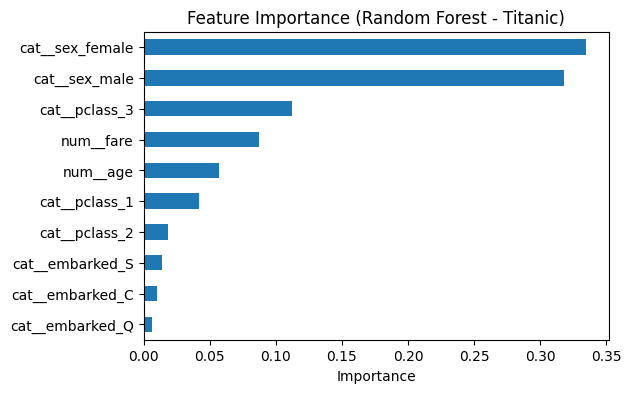

In [186]:
#@title Feature Importance (Random Forest - Titanic) { display-mode: "form", run: "auto" }

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 🔹 Extract feature names
# =========================
titanic_feature_names = titanic_rf_model.named_steps["preprocessor"].get_feature_names_out()

# =========================
# 🔹 Extract importances
# =========================
titanic_importances = titanic_rf_model.named_steps["classifier"].feature_importances_

# =========================
# 🔹 Create series
# =========================
titanic_feat_imp = pd.Series(titanic_importances, index=titanic_feature_names)

# =========================
# 🔹 Plot
# =========================
plt.figure(figsize=(6,4))

titanic_feat_imp.sort_values().plot(kind="barh")

plt.title("Feature Importance (Random Forest - Titanic)")
plt.xlabel("Importance")

plt.show()

---
## 🌳 Looking Inside the Model: A Single Decision Tree

A random forest is made up of **many decision trees**.

To better understand how it works, we can inspect **one individual tree**.

---

## 🧠 Why look at a single tree?

- It shows the **decision rules** the model learns  
- Helps us understand how features are used step-by-step  
- Makes the model more interpretable  

---

## 🔍 What you’ll see

Each node represents a decision:

- A feature and threshold (e.g., `age < 30`)  
- A split into two branches  
- A prediction at the leaves  

---

## 👀 What to look for

- Which features appear near the top? (more important)  
- How are decisions being split?  
- Does the logic make intuitive sense?  

---

## 🧭 Key Idea

> A random forest is just **many simple decision rules combined together**.

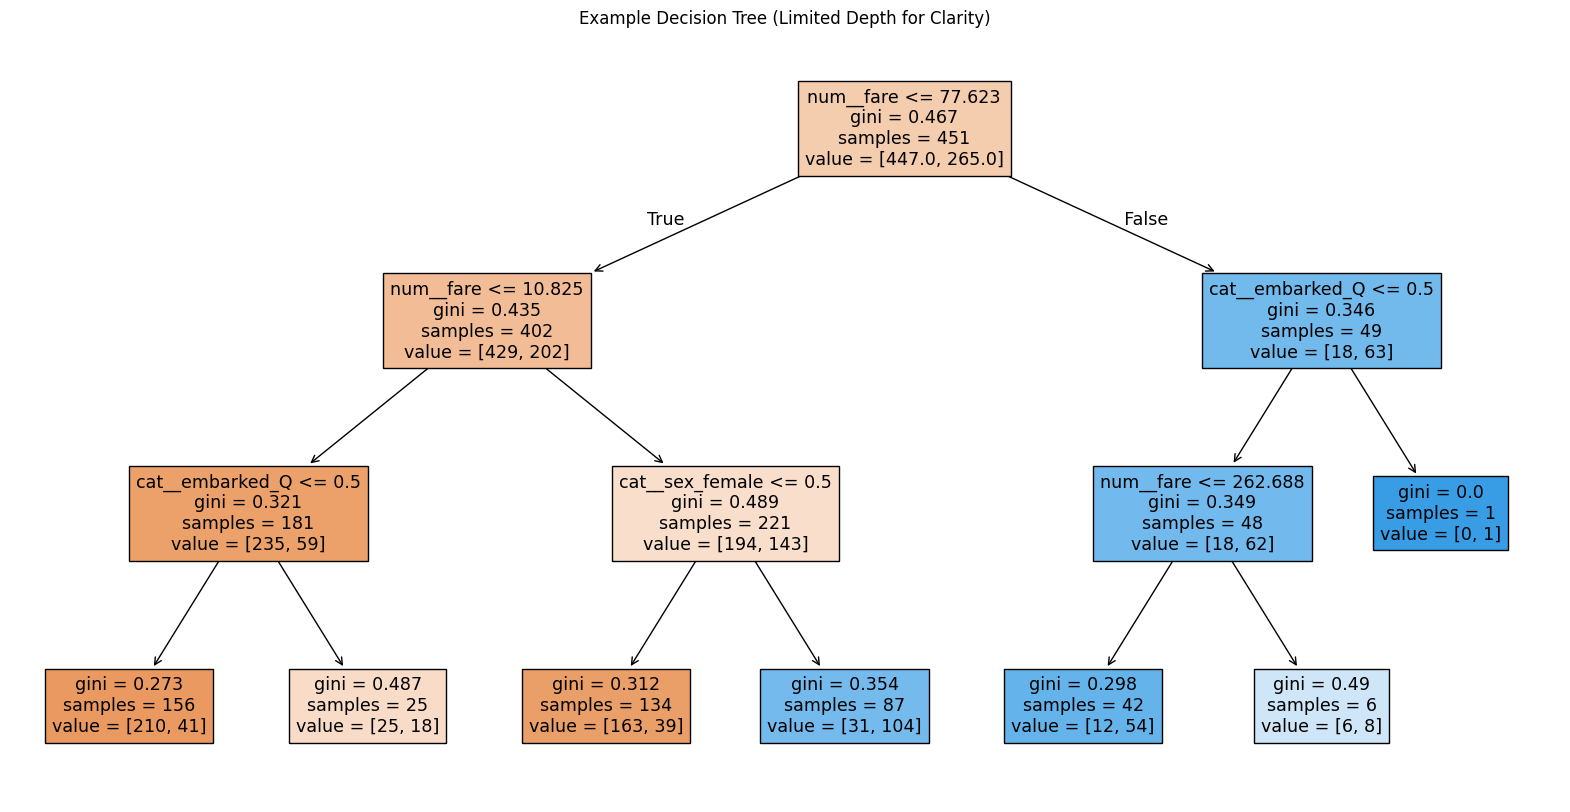

In [189]:
#@title Visualize a Single Decision Tree (Random Forest - Titanic) { display-mode: "form", run: "auto" }

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# =========================
# 🔹 Extract one tree
# =========================
titanic_tree = titanic_rf_model.named_steps["classifier"].estimators_[0]

# =========================
# 🔹 Feature names
# =========================
titanic_feature_names = titanic_rf_model.named_steps["preprocessor"].get_feature_names_out()

# =========================
# 🔹 Plot
# =========================
plt.figure(figsize=(20, 10))

plot_tree(
    titanic_tree,
    feature_names=titanic_feature_names,
    filled=True,
)

plt.title("Example Decision Tree (Limited Depth for Clarity)")
plt.show()

---
# 🧠 Neural Network (MLP) - Titanic

Now we compare a different type of model: a **neural network**.

Unlike decision trees and random forests, neural networks learn by transforming the data through multiple layers of computation.

<p align="center">
  <img src="https://raw.githubusercontent.com/Hunter174/GentleIntroToML/main/assets/neural-network.png" width="400"/>
</p>

---

## 🧩 How it works

- Input features pass through multiple **layers**
- Each layer applies transformations using weights and nonlinear functions
- The network builds increasingly complex representations
- The final layer produces class probabilities

---

## ⚙️ Key Hyperparameters

Neural networks are flexible, but require tuning:

- **Hidden Layers (`hidden_layer_sizes`)**  
  → More layers = more expressive, but risk of overfitting  

- **Activation Function (`activation`)**  
  → Controls how signals flow through the network  

- **Regularization (`alpha`)**  
  → Prevents overly complex models  

- **Training Iterations (`max_iter`)**  
  → Controls how long the model learns  

---

## 👀 What to observe

- Does the neural network outperform the random forest?  
- Is the improvement significant or marginal?  
- What tradeoffs are we making?  

---

## ⚖️ Key Tradeoff

- Random Forest → more interpretable, easier to trust  
- Neural Network → more flexible, but harder to interpret  

---

## 🧭 Key Idea

> More complex models are not always better —  
> they introduce tradeoffs between performance and interpretability.

---

For an interactive, visual explanation, see:  
🔗 https://mlu-explain.github.io/neural-networks/

In [190]:
#@title Neural Network (MLP) - Titanic

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# =========================
# 🔹 Model Pipeline
# =========================
titanic_mlp_model = Pipeline(steps=[
    ("preprocessor", titanic_preprocessor),
    ("scaler", StandardScaler(with_mean=False)),  # required for sparse one-hot output
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64, 32, 16),
        activation="relu",
        alpha=0.001,
        max_iter=1000,
        random_state=42
    ))
])

# =========================
# 🔹 Train
# =========================
titanic_mlp_model.fit(titanic_X_train, titanic_y_train)

# =========================
# 🔹 Evaluate
# =========================
accuracy = titanic_mlp_model.score(titanic_X_test, titanic_y_test)
print(f"MLP Accuracy: {accuracy:.3f}")

MLP Accuracy: 0.810


---
## 🤔 Is a higher accuracy always better?

We just saw:

- Neural Network → ~81% accuracy  
- Random Forest → ~79% accuracy  

So the neural network is better… right?

---

## ⚖️ Not necessarily

While the neural network performs slightly better, we need to ask:

- Can we understand how it makes decisions?  
- Can we explain its predictions to others?  
- Can we trust it in critical situations?  

---

## 🔍 Interpretable vs Black Box Models

- **Random Forest**  
  - We can inspect feature importance  
  - We can visualize individual trees  
  - Easier to explain decisions  

- **Neural Network**  
  - Many layers of transformations  
  - Thousands of learned parameters  
  - Hard to interpret directly  

---

## 🧠 Why are neural networks called “black boxes”?

Because we can see:

- The inputs  
- The outputs  

But the internal decision process is difficult to interpret.

---

## 🧭 Key Idea

> A small gain in accuracy may not be worth losing interpretability.

---

## 👀 What to observe

- How complex is the network structure?  
- Can you follow how a decision is made?  
- Compare this to the decision tree you saw earlier

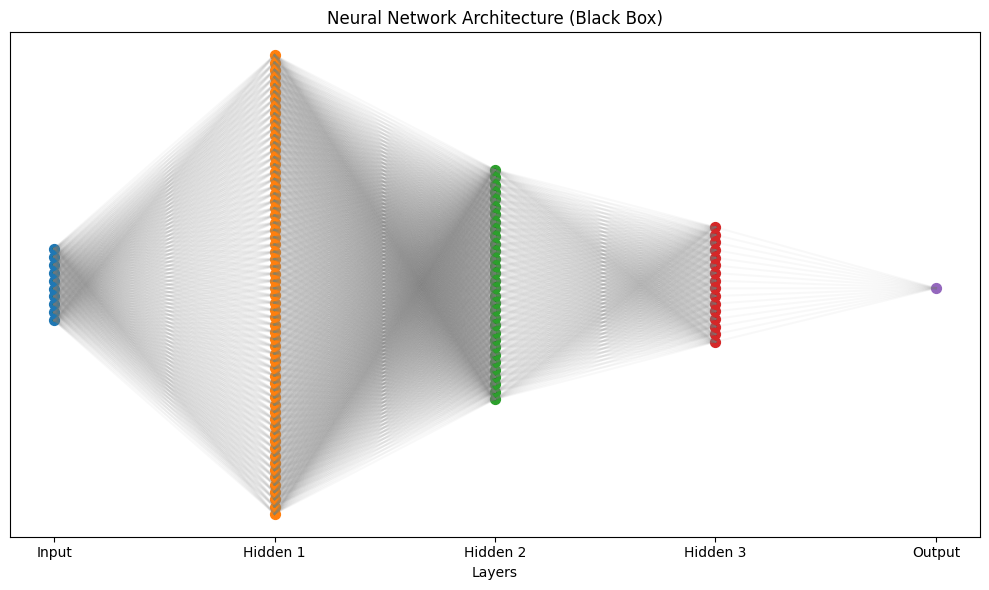

In [191]:
#@title Neural Network Architecture (Black Box Visualization) { display-mode: "form", run: "auto" }

import matplotlib.pyplot as plt
import numpy as np

# =========================
# 🔹 Extract trained model
# =========================
titanic_mlp = titanic_mlp_model.named_steps["classifier"]

# =========================
# 🔹 Get layer sizes
# =========================
layer_sizes = [titanic_mlp.n_features_in_] + list(titanic_mlp.hidden_layer_sizes) + [titanic_mlp.n_outputs_]

plt.figure(figsize=(10, 6))

max_neurons = max(layer_sizes)

# =========================
# 🔹 Plot nodes
# =========================
for i, layer_size in enumerate(layer_sizes):
    y_positions = np.linspace(
        (max_neurons - layer_size) / 2,
        (max_neurons + layer_size) / 2,
        layer_size
    )
    x_positions = [i] * layer_size

    plt.scatter(x_positions, y_positions, s=50)

# =========================
# 🔹 Draw connections
# =========================
for i in range(len(layer_sizes) - 1):
    layer1 = layer_sizes[i]
    layer2 = layer_sizes[i + 1]

    y1 = np.linspace((max_neurons - layer1) / 2,
                     (max_neurons + layer1) / 2,
                     layer1)

    y2 = np.linspace((max_neurons - layer2) / 2,
                     (max_neurons + layer2) / 2,
                     layer2)

    for j in range(layer1):
        for k in range(layer2):
            plt.plot([i, i+1], [y1[j], y2[k]], alpha=0.05, color="gray")

# =========================
# 🔹 Labels
# =========================
labels = ["Input"] + \
         [f"Hidden {i+1}" for i in range(len(layer_sizes) - 2)] + \
         ["Output"]

plt.xticks(range(len(layer_sizes)), labels)
plt.yticks([])

plt.title("Neural Network Architecture (Black Box)")
plt.xlabel("Layers")

plt.tight_layout()
plt.show()

---


---
# 🚀 Putting It All Together: Solving a Nonlinear Problem

Now it’s your turn.

We will revisit a challenging dataset: **Two Moons**.

---

## 🌙 The challenge

This dataset is **not linearly separable**, meaning:

- Simple models may struggle  
- More flexible models may perform better  

---

## 🎯 Your goal

Use what you've learned to:

- Select a model  
- Tune its hyperparameters  
- Evaluate its performance  
- Understand how it makes decisions  

---

## 🧠 What to try

- Start with **Logistic Regression** → observe limitations  
- Try **Random Forest** → notice piecewise boundaries  
- Try **Neural Network** → look for smooth nonlinear separation  

---

## 👀 What to observe

- How does the decision boundary change?  
- Which model performs best?  
- Is higher accuracy always the best choice?  

---

## 🧭 Final Insight

> Machine learning is not just about choosing the best model —  
> it's about understanding the **tradeoffs between simplicity, performance, and interpretability**.

Model: Logistic Regression
Accuracy: 0.860


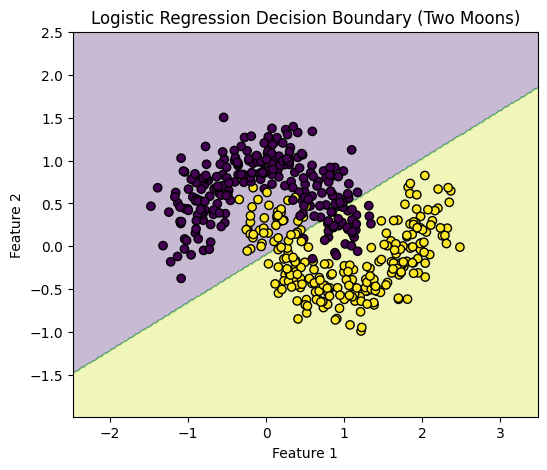

In [193]:
#@title Putting It All Together: Model Comparison on Two Moons { display-mode: "form", run: "auto" }

# =========================
# 🔹 Model Selection
# =========================
#@markdown ### 🔀 Select Model
Model_Type = "Logistic Regression" #@param ["Logistic Regression", "Random Forest", "MLP"]

# =========================
# 🔹 Logistic Regression Params
# =========================
#@markdown ---
#@markdown ### Logistic Regression Hyperparameters
C = 0.07 #@param {type:"slider", min:0.01, max:10.0, step:0.01}

# =========================
# 🔹 Random Forest Params
# =========================
#@markdown ---
#@markdown ### Random Forest Hyperparameters
Num_Trees = 74 #@param {type:"slider", min:1, max:200, step:1}
Max_Depth = 9 #@param {type:"slider", min:1, max:20, step:1}

# =========================
# 🔹 Neural Network Params
# =========================
#@markdown ---
#@markdown ### Neural Network (MLP) Hyperparameters
Hidden_Layers = "(64, 32)" #@param {type:"string"}
Activation = "tanh" #@param ["relu", "tanh", "logistic"]
Alpha = 0.01 #@param {type:"number"}
Max_Iterations = 1000 #@param {type:"integer"}

# =========================
# 🔹 Imports
# =========================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# =========================
# 🔹 Data (Two Moons)
# =========================
moons_X, moons_y = make_moons(n_samples=500, noise=0.2, random_state=42)

moons_X_train, moons_X_test, moons_y_train, moons_y_test = train_test_split(
    moons_X, moons_y, test_size=0.2, random_state=42
)

# =========================
# 🔹 Model Selection
# =========================
if Model_Type == "Logistic Regression":
    moons_model = LogisticRegression(C=C, max_iter=1000)

elif Model_Type == "Random Forest":
    moons_model = RandomForestClassifier(
        n_estimators=Num_Trees,
        max_depth=Max_Depth,
        random_state=42
    )

elif Model_Type == "MLP":
    hidden_layers = tuple(int(x.strip()) for x in Hidden_Layers.strip("()").split(","))
    moons_model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=Activation,
        alpha=Alpha,
        max_iter=Max_Iterations,
        random_state=42
    )

# =========================
# 🔹 Train + Evaluate
# =========================
moons_model.fit(moons_X_train, moons_y_train)
accuracy = moons_model.score(moons_X_test, moons_y_test)

print(f"Model: {Model_Type}")
print(f"Accuracy: {accuracy:.3f}")

# =========================
# 🔹 Decision Boundary
# =========================
x_min, x_max = moons_X[:, 0].min() - 1, moons_X[:, 0].max() + 1
y_min, y_max = moons_X[:, 1].min() - 1, moons_X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = moons_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# =========================
# 🔹 Plot
# =========================
plt.figure(figsize=(6,5))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

plt.scatter(
    moons_X[:, 0],
    moons_X[:, 1],
    c=moons_y,
    cmap="viridis",
    edgecolor="k"
)

plt.title(f"{Model_Type} Decision Boundary (Two Moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

---
# 📚 Going Beyond Today’s Workshop

If you want to continue learning, here are some high-quality resources that provide intuitive explanations, visualizations, and deeper dives into machine learning concepts.

---

## 🌐 Interactive Learning

- 🔗 https://mlu-explain.github.io  
  Clear, interactive explanations of core ML concepts  

- 🔗 https://playground.tensorflow.org/  
  Hands-on neural network visualization and experimentation  

---

## 🎥 Intuitive Video Explanations

- 🔗 https://www.youtube.com/c/3blue1brown  
  Exceptional visual explanations of math and deep learning concepts  

- 🔗 https://www.youtube.com/c/joshstarmer  
  Clear, step-by-step explanations of statistics and machine learning  

---

## 🧠 Structured Learning

- 🔗 https://www.freecodecamp.org  
  Full courses and tutorials across data science and ML  

- 🔗 https://huggingface.co/blog/info5ec/ml-dl-mastery-guide  
  A curated roadmap for mastering machine learning and deep learning  

- 🔗 https://www.w3schools.com/python/default.asp  
  Beginner-friendly Python reference and quick syntax lookup  

---

## 🧭 Final Advice

- Focus on building **intuition**, not just memorizing techniques  
- Experiment with models and datasets  
- Try to explain concepts in your own words  

> The best way to learn machine learning is to **build, visualize, and question everything**